In [1]:
# Imports
import pandas as pd
import numpy as np
import torch as pt
import torch.nn as nn

In [3]:
# Load and prep data

df = pd.read_csv('data/raw/fhfa-hpi-data.csv')
df['Date'] = pd.to_datetime(df['Date']) # Instantiates the dates as Datetime objects
df = df.sort_values('Date').reset_index(drop=True)
df['HPI_YoY'] = df['Index'].pct_change(12) * 100
df = df.dropna()[['Date', 'HPI_YoY']]

In [4]:
# Create X (current) and y (next month) pairs
X = df['HPI_YoY'].values[:-1].reshape(-1, 1) 
y = df['HPI_YoY'].values[1:].reshape(-1, 1)

In [5]:
# Normalize with numpy (z-score)
X_mean, X_std = X.mean(), X.std()
X_scaled = (X - X_mean) / X_std

In [6]:
# Train/test split (keep time order)
split_idx = int(len(X) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [7]:
# Convert to tensors
X_train = pt.FloatTensor(X_train)
X_test = pt.FloatTensor(X_test)
y_train = pt.FloatTensor(y_train)
y_test = pt.FloatTensor(y_test)

In [8]:
# The Neural Network
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

In [13]:
# Initialize
model = SimpleNN()
criterion = nn.MSELoss()
optimizer = pt.optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 500
for epoch in range(epochs):
    # Forward pass
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# Evaluate on test set
model.eval()
with pt.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f'\nTest Loss: {test_loss.item():.4f}')

Epoch 50/500, Loss: 3.2068
Epoch 100/500, Loss: 0.2992
Epoch 150/500, Loss: 0.2560
Epoch 200/500, Loss: 0.2325
Epoch 250/500, Loss: 0.2195
Epoch 300/500, Loss: 0.2140
Epoch 350/500, Loss: 0.2120
Epoch 400/500, Loss: 0.2109
Epoch 450/500, Loss: 0.2103
Epoch 500/500, Loss: 0.2099

Test Loss: 0.6465


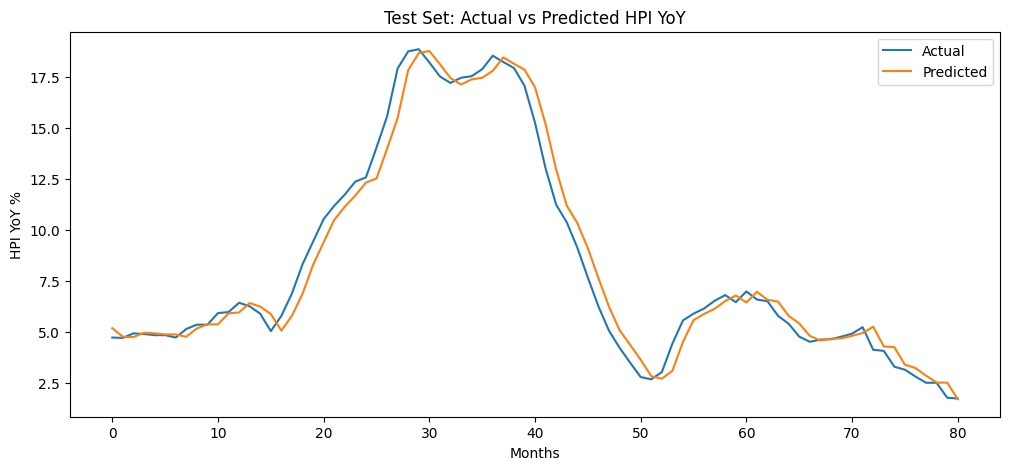

In [14]:
# Visualization with matplotlib

import matplotlib.pyplot as plt

model.eval()
with pt.no_grad():
    test_pred = model(X_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test.numpy().flatten(), label='Actual')
plt.plot(test_pred.numpy().flatten(), label='Predicted')
plt.xlabel('Months')
plt.ylabel('HPI YoY %')
plt.title('Test Set: Actual vs Predicted HPI YoY')
plt.legend()
plt.show()